In [1]:
import xarray as xr
import os
import glob
import geopandas as gpd
import pandas as pd
import numpy as np
import re
from scipy.stats import linregress
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib.pyplot as plt
import regionmask


In [ ]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)

Mun_of_Anc_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Municipality of Anchorage']
Bethel_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Bethel Census Area']
Mat_Su_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Matanuska-Susitna Borough']
Denali_boundary=borough_boundaries[borough_boundaries['CommunityN'] == 'Denali Borough']

FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)

In [3]:
#Regridded ERA5 31km
regridded_era5_path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ERA5_31kmto4km_nearest_regridded.nc'
regridded_era5=xr.open_dataset(regridded_era5_path)

#ERA5  4km
era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Monthly_*.nc'
era5_4km = xr.open_mfdataset(era5_4km,combine="by_coords", parallel=True)

os.chdir("/import/beegfs/CMIP6/wrf_era5")
geo_em_path = "geo_em.d02.nc"
geo = xr.open_dataset(geo_em_path)
oceanmask=geo['LU_INDEX']
oceanmask=oceanmask.squeeze(dim='Time')

era5_4km = era5_4km.where(oceanmask != 17)
regridded_era5 = regridded_era5.where(oceanmask != 17)


In [4]:
geo

<xarray.Dataset> Size: 102MB
Dimensions:     (Time: 1, south_north: 450, west_east: 420,
                 south_north_stag: 451, west_east_stag: 421, land_cat: 21,
                 soil_cat: 16, month: 12)
Dimensions without coordinates: Time, south_north, west_east, south_north_stag,
                                west_east_stag, land_cat, soil_cat, month
Data variables: (12/53)
    Times       (Time) |S19 19B ...
    XLAT_M      (Time, south_north, west_east) float32 756kB ...
    XLONG_M     (Time, south_north, west_east) float32 756kB ...
    XLAT_V      (Time, south_north_stag, west_east) float32 758kB ...
    XLONG_V     (Time, south_north_stag, west_east) float32 758kB ...
    XLAT_U      (Time, south_north, west_east_stag) float32 758kB ...
    ...          ...
    OL1         (Time, south_north, west_east) float32 756kB ...
    OL2         (Time, south_north, west_east) float32 756kB ...
    OL3         (Time, south_north, west_east) float32 756kB ...
    OL4         (Time, south_north, west_east) float32 756kB ...
    VAR_SSO     (Time, south_north, west_east) float32 756kB ...
    LAKE_DEPTH  (Time, south_north, west_east) float32 756kB ...
Attributes: (12/48)
    TITLE:                           OUTPUT FROM GEOGRID V4.5
    SIMULATION_START_DATE:           0000-00-00_00:00:00
    WEST-EAST_GRID_DIMENSION:        421
    SOUTH-NORTH_GRID_DIMENSION:      451
    BOTTOM-TOP_GRID_DIMENSION:       0
    WEST-EAST_PATCH_START_UNSTAG:    1
    ...                              ...
    sr_x:                            1
    sr_y:                            1
    FLAG_MF_XY:                      1
    FLAG_LAI12M:                     1
    FLAG_VAR_SSO:                    1
    FLAG_LAKE_DEPTH:                 1

In [5]:
seasons=era5_4km['season']
lat=era5_4km['XLAT']
lon=era5_4km['XLONG']

monthlist=['November','December','January','February','March' ]
monthnumberlist=[11,12,1,2,3]

In [6]:
ros_seasonal_total_4km=era5_4km['ros_tally'].sum(axis=1)
ros_seasonal_total_31km=regridded_era5['ros_tally'].sum(axis=1)
#ros_rain_sum_season_total_SUM_4km=era5_4km['rain_ros_sum'].sum(axis=1).mean(axis=0)

In [7]:
'''ros_hourly_totals_climatology = []
for i in range(len(ros_seasonal_total_4km.season)):
    val = ros_seasonal_total_4km.isel(season=i).sum().compute().item()
    ros_hourly_totals_climatology.append(val)


n_pixels_per_season = []

for i in range(len(ros_seasonal_total_4km.season)):
    ros_this_season = ros_seasonal_total_4km.isel(season=i)
    # Create a boolean mask of where ROS occurred (value > 0)
    grid_with_ros = ros_this_season > 0
    # Count how many grid cells had ROS
    n_pixels = grid_with_ros.sum().compute().item()
    n_pixels_per_season.append(n_pixels)

ros_hours_normalized = [total / n if n > 0 else np.nan 
                        for total, n in zip(ros_hourly_totals_climatology, n_pixels_per_season)]
seasons = [str(s) for s in ros_seasonal_total_4km.season.values]
'''


'ros_hourly_totals_climatology = []\nfor i in range(len(ros_seasonal_total_4km.season)):\n    val = ros_seasonal_total_4km.isel(season=i).sum().compute().item()\n    ros_hourly_totals_climatology.append(val)\n\n\nn_pixels_per_season = []\n\nfor i in range(len(ros_seasonal_total_4km.season)):\n    ros_this_season = ros_seasonal_total_4km.isel(season=i)\n    # Create a boolean mask of where ROS occurred (value > 0)\n    grid_with_ros = ros_this_season > 0\n    # Count how many grid cells had ROS\n    n_pixels = grid_with_ros.sum().compute().item()\n    n_pixels_per_season.append(n_pixels)\n\nros_hours_normalized = [total / n if n > 0 else np.nan \n                        for total, n in zip(ros_hourly_totals_climatology, n_pixels_per_season)]\nseasons = [str(s) for s in ros_seasonal_total_4km.season.values]\n'

In [8]:
def compute_ros_hours_normalized(data):
    """Compute total ROS hours per season, number of pixels with ROS per season,
    and normalized ROS hours (total / number of pixels)
    
    seasons : season labels
    ros_hourly_totals_climatology  Total ROS hours per season
    n_pixels_per_season : Number of pixels with ROS per season
    ros_hours_normalized : Normalized ROS hours per season"""

    ros_hourly_totals_climatology = []
    n_pixels_per_season = []

    for i in range(len(data.season)):
        ros_this_season = data.isel(season=i)
        # Total ROS hours
        total = ros_this_season.sum().compute().item()
        ros_hourly_totals_climatology.append(total)
        # Count pixels with ROS (> 0)
        grid_with_ros = ros_this_season > 0
        n_pixels = grid_with_ros.sum().compute().item()
        n_pixels_per_season.append(n_pixels)

    ros_hours_normalized = [
        total / n if n > 0 else 0
        for total, n in zip(ros_hourly_totals_climatology, n_pixels_per_season)]

    seasons = [str(s) for s in data.season.values]

    return seasons, ros_hourly_totals_climatology, n_pixels_per_season, ros_hours_normalized

In [9]:
seasons, totals_4s, n_pixels_4s, statewide_4km_normalized = compute_ros_hours_normalized(ros_seasonal_total_4km)

seasons, totals_31s, n_pixels_31s, statewide_31km_normalized = compute_ros_hours_normalized(ros_seasonal_total_31km)

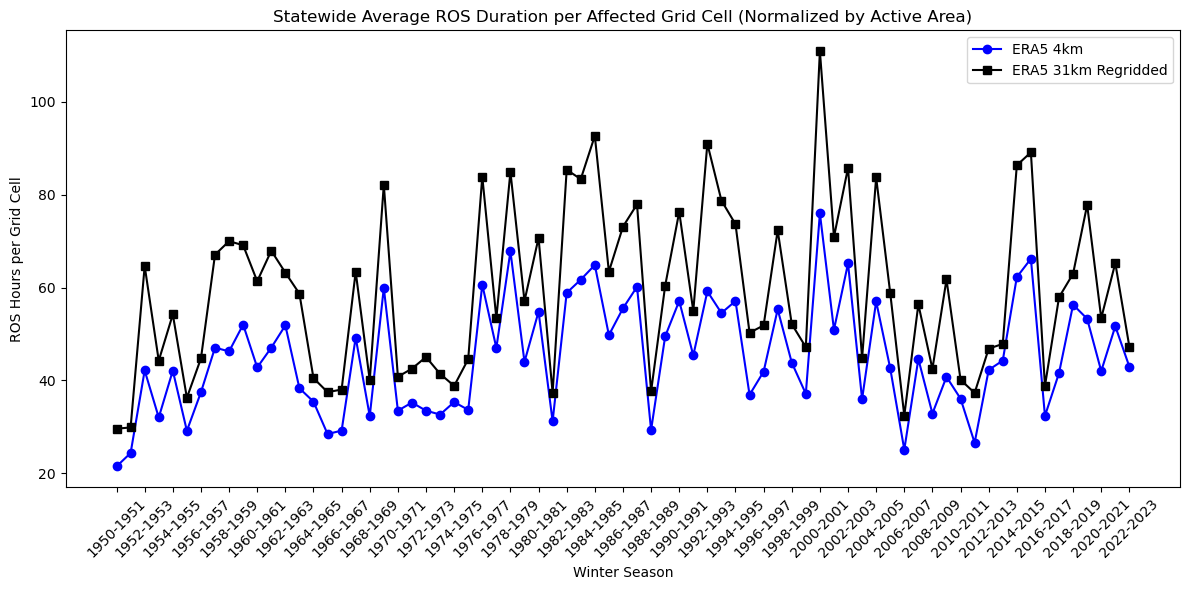

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(seasons, statewide_4km_normalized, marker='o', linestyle='-', color='blue',label='ERA5 4km')
plt.plot(seasons, statewide_31km_normalized, marker='s', linestyle='-', color='black',label='ERA5 31km Regridded')
plt.title('Statewide Average ROS Duration per Affected Grid Cell (Normalized by Active Area)')
plt.xlabel('Winter Season')
plt.ylabel('ROS Hours per Grid Cell')
plt.xticks(ticks=range(0, len(seasons), 2), labels=seasons[::2], rotation=45)
plt.tight_layout()
plt.legend()
#fig.patch.set_alpha(0.0)
plt.show()

In [11]:
def borough_land_mask(shapefile,data,lat,lon):
    mask = regionmask.mask_geopandas(shapefile, lon, lat)
    data_masked = data.where(~np.isnan(mask))
    return data_masked

In [12]:
anc_only_ros_4km = borough_land_mask(Mun_of_Anc_boundary, ros_seasonal_total_4km, lat, lon)
anc_only_ros_31km = borough_land_mask(Mun_of_Anc_boundary, ros_seasonal_total_31km, lat, lon)
seasons_4anc, totals_4s_anc, n_pixels_4s_anc, anc_4km_normalized = compute_ros_hours_normalized(anc_only_ros_4km)
seasons_31anc, totals_31s_anc, n_pixels_31s_anc, anc_31km_normalized = compute_ros_hours_normalized(anc_only_ros_31km)

fai_only_ros_4km = borough_land_mask(FNSB_boundary, ros_seasonal_total_4km, lat, lon)
fai_only_ros_31km = borough_land_mask(FNSB_boundary, ros_seasonal_total_31km, lat, lon)
seasons_4fai, totals_4s_fai, n_pixels_4s_fai, fai_4km_normalized = compute_ros_hours_normalized(fai_only_ros_4km)
seasons_31fai, totals_31s_fai, n_pixels_31s_fai, fai_31km_normalized = compute_ros_hours_normalized(fai_only_ros_31km)

bet_only_ros_4km = borough_land_mask(Bethel_boundary, ros_seasonal_total_4km, lat, lon)
bet_only_ros_31km = borough_land_mask(Bethel_boundary, ros_seasonal_total_31km, lat, lon)
seasons_4bet, totals_4s_bet, n_pixels_4s_bet, bet_4km_normalized = compute_ros_hours_normalized(bet_only_ros_4km)
seasons_31bet, totals_31s_bet, n_pixels_31s_bet, bet_31km_normalized = compute_ros_hours_normalized(bet_only_ros_31km)


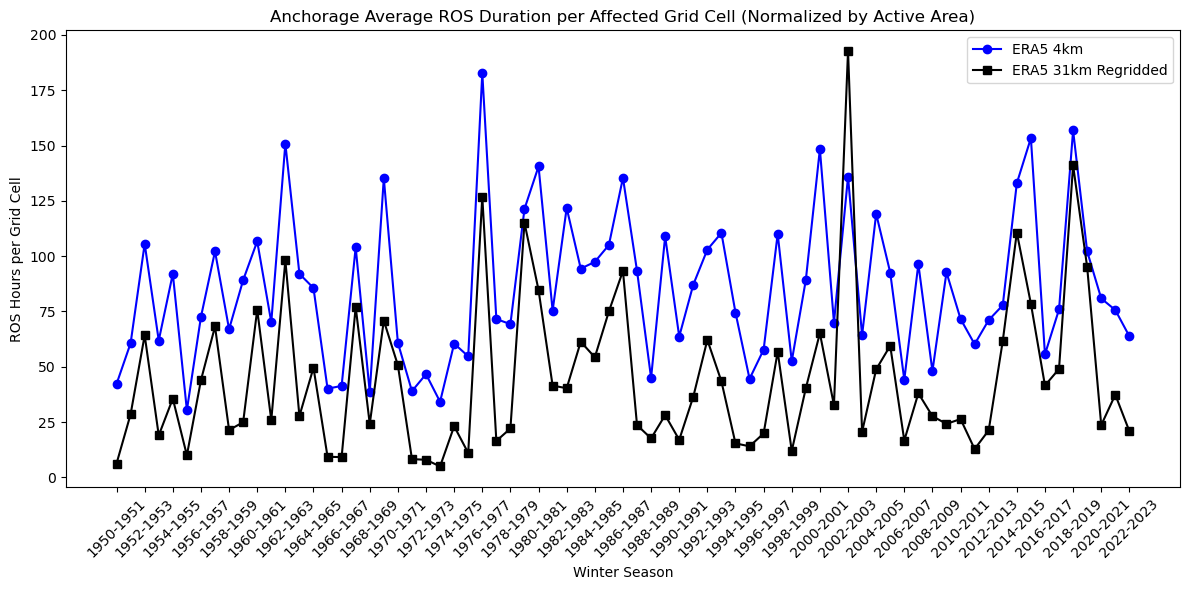

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(seasons_4anc, anc_4km_normalized, marker='o', linestyle='-', color='blue',label='ERA5 4km')
plt.plot(seasons_31anc, anc_31km_normalized, marker='s', linestyle='-', color='black',label='ERA5 31km Regridded')
plt.title('Anchorage Average ROS Duration per Affected Grid Cell (Normalized by Active Area)')
plt.xlabel('Winter Season')
plt.ylabel('ROS Hours per Grid Cell')
plt.xticks(ticks=range(0, len(seasons), 2), labels=seasons[::2], rotation=45)
plt.tight_layout()
plt.legend()
#fig.patch.set_alpha(0.0)
plt.show()

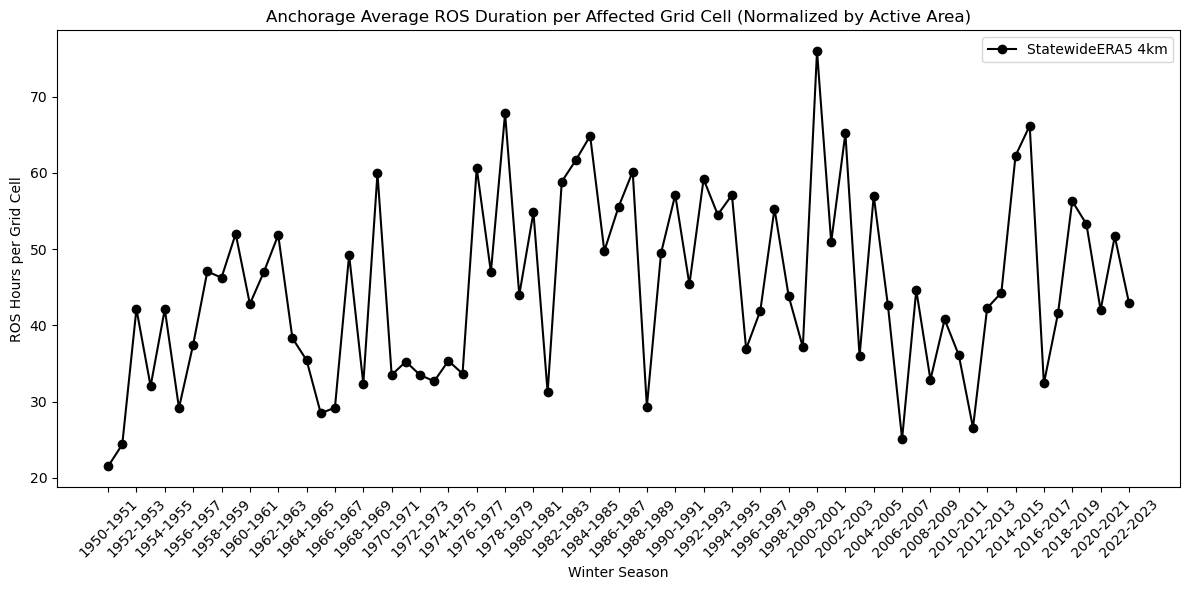

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(seasons_4anc, statewide_4km_normalized, marker='o', linestyle='-', color='black',label='StatewideERA5 4km')
#plt.plot(seasons_31anc, anc_4km_normalized, marker='s', linestyle='-', color='red',label='Anc ERA5 4km ')
plt.title('Anchorage Average ROS Duration per Affected Grid Cell (Normalized by Active Area)')
plt.xlabel('Winter Season')
plt.ylabel('ROS Hours per Grid Cell')
plt.xticks(ticks=range(0, len(seasons), 2), labels=seasons[::2], rotation=45)
plt.tight_layout()
plt.legend()
#fig.patch.set_alpha(0.0)
plt.show()

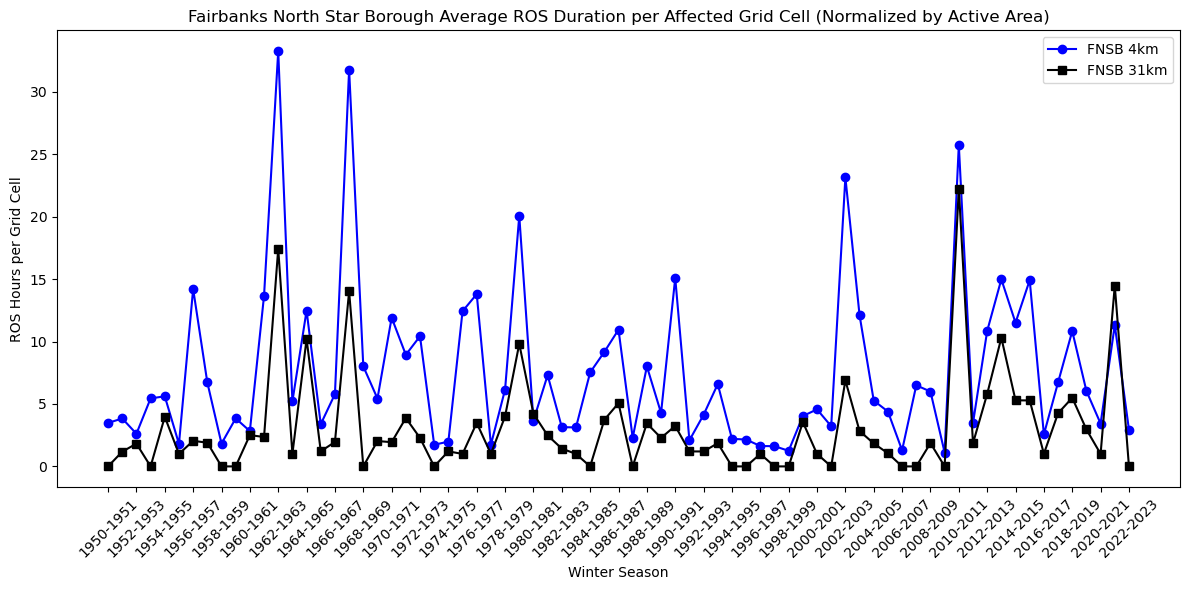

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(seasons_4fai, fai_4km_normalized, marker='o', linestyle='-', color='blue',label='FNSB 4km')
plt.plot(seasons_31fai, fai_31km_normalized, marker='s', linestyle='-', color='black',label='FNSB 31km')
plt.title('Fairbanks North Star Borough Average ROS Duration per Affected Grid Cell (Normalized by Active Area)')
plt.xlabel('Winter Season')
plt.ylabel('ROS Hours per Grid Cell')
plt.xticks(ticks=range(0, len(seasons_4fai), 2), labels=seasons_4fai[::2], rotation=45)
plt.tight_layout()
plt.legend()
#fig.patch.set_alpha(0.0)
plt.show()

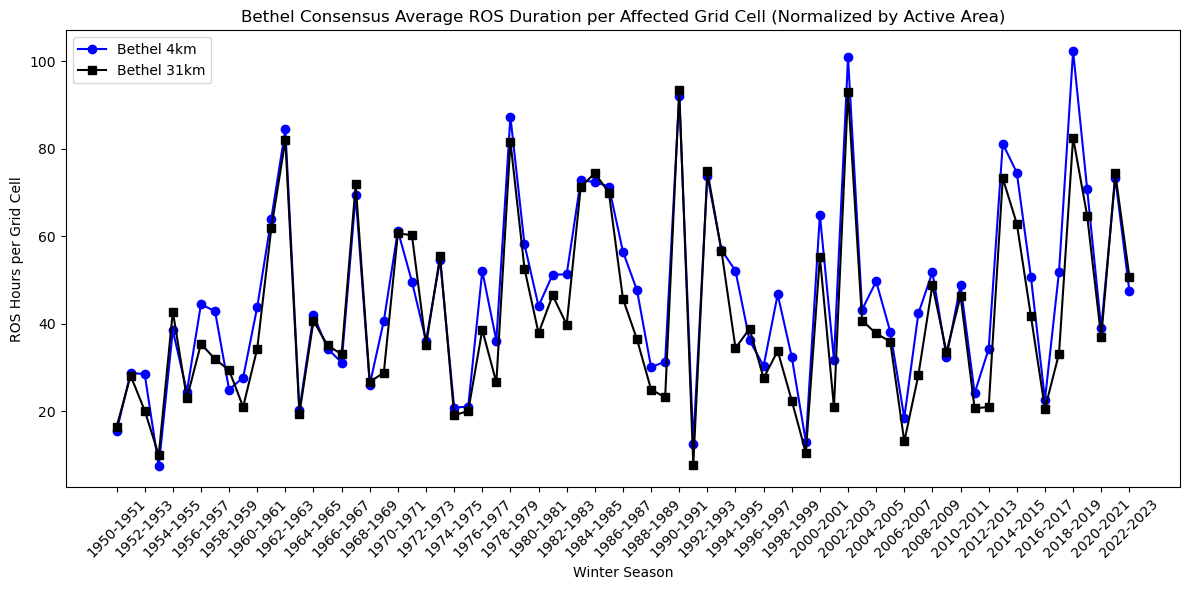

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(seasons_4bet, bet_4km_normalized, marker='o', linestyle='-', color='blue',label='Bethel 4km')
plt.plot(seasons_31bet, bet_31km_normalized, marker='s', linestyle='-', color='black',label='Bethel 31km')
plt.title('Bethel Consensus Average ROS Duration per Affected Grid Cell (Normalized by Active Area)')
plt.xlabel('Winter Season')
plt.ylabel('ROS Hours per Grid Cell')
plt.xticks(ticks=range(0, len(seasons_4bet), 2), labels=seasons_4bet[::2], rotation=45)
plt.tight_layout()
plt.legend()
#fig.patch.set_alpha(0.0)
plt.show()

In [17]:
#ros_seasonal_total_4km
#ros_seasonal_total_31km

In [18]:
start_years = np.array([int(s.split('-')[0]) for s in seasons])
decades_assigned = (start_years // 10) * 10

In [19]:
statewide_4km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": statewide_4km_normalized
})
statewide_31km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": statewide_31km_normalized})

decadal_means_4km = statewide_4km_decadal_df.groupby("decade")["normalized"].mean()
decadal_means_31km = statewide_31km_decadal_df.groupby("decade")["normalized"].mean()



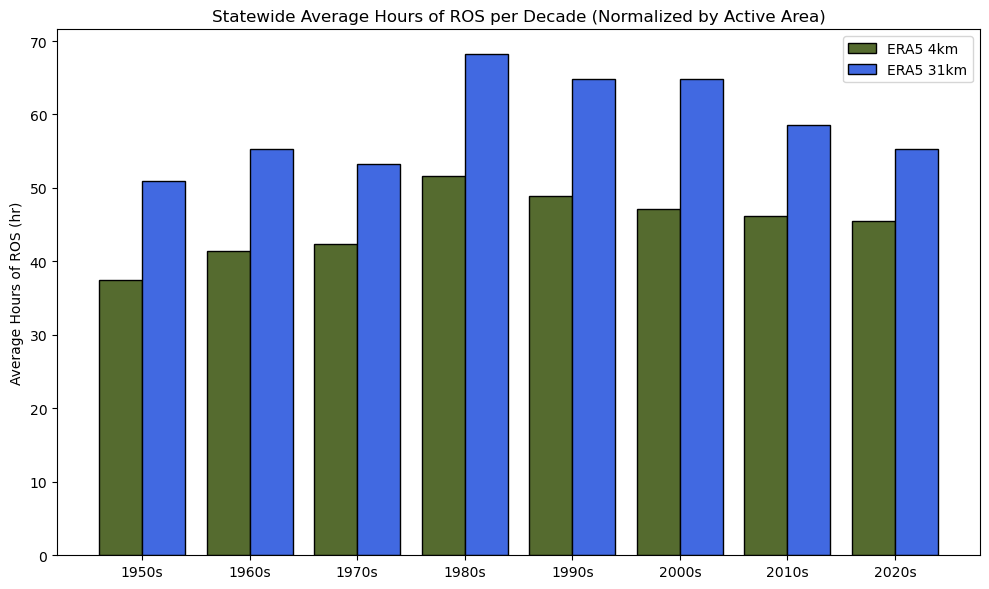

In [20]:
decades=['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

x = np.arange(len(decades))
width = 0.40
fig, ax = plt.subplots(figsize=(10,6))


ax.bar(x - 0.5*width, decadal_means_4km, width, color='darkolivegreen', edgecolor='black', label='ERA5 4km')
ax.bar(x + 0.5*width, decadal_means_31km, width, color='royalblue', edgecolor='black', label='ERA5 31km')

ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_ylabel('Average Hours of ROS (hr)')

ax.set_title('Statewide Average Hours of ROS per Decade (Normalized by Active Area)')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
anc_4km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": anc_4km_normalized
})
anc_31km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": anc_31km_normalized})

anc_decadal_means_4km = anc_4km_decadal_df.groupby("decade")["normalized"].mean()
anc_decadal_means_31km = anc_31km_decadal_df.groupby("decade")["normalized"].mean()

fai_4km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": fai_4km_normalized
})
fai_31km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": fai_31km_normalized})

fai_decadal_means_4km = fai_4km_decadal_df.groupby("decade")["normalized"].mean()
fai_decadal_means_31km = fai_31km_decadal_df.groupby("decade")["normalized"].mean()

In [23]:
bet_4km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": bet_4km_normalized
        })


bet_31km_decadal_df = pd.DataFrame({
    "season": seasons,
    "start_year": start_years,
    "decade": decades_assigned,
    "normalized": bet_31km_normalized})

bet_decadal_means_4km = bet_4km_decadal_df.groupby("decade")["normalized"].mean()
bet_decadal_means_31km = bet_31km_decadal_df.groupby("decade")["normalized"].mean()


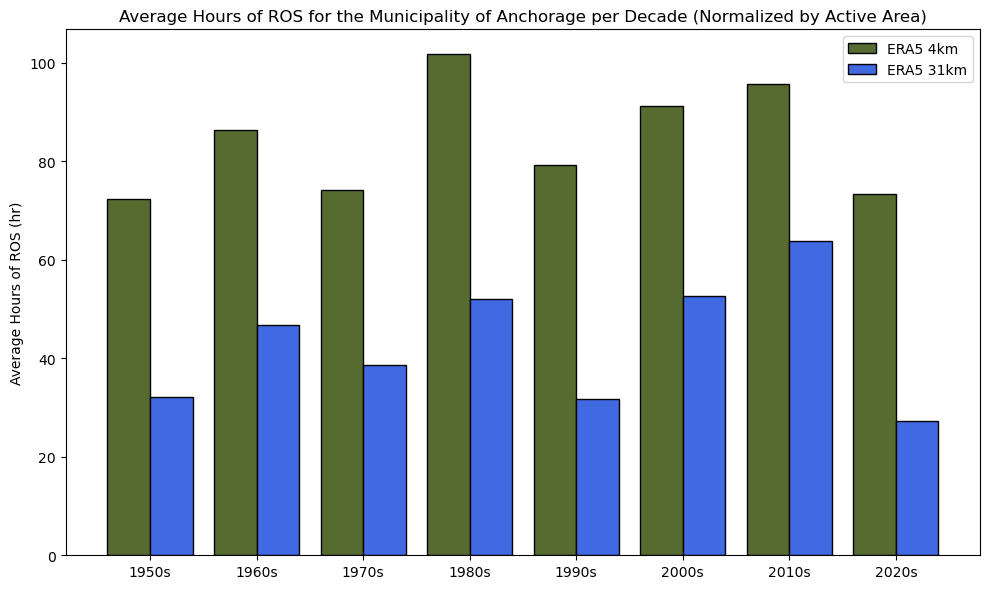

In [24]:
decades=['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

x = np.arange(len(decades))
width = 0.40
fig, ax = plt.subplots(figsize=(10,6))


ax.bar(x - 0.5*width, anc_decadal_means_4km , width, color='darkolivegreen', edgecolor='black', label='ERA5 4km')
ax.bar(x + 0.5*width, anc_decadal_means_31km , width, color='royalblue', edgecolor='black', label='ERA5 31km')

ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_ylabel('Average Hours of ROS (hr)')
ax.set_title('Average Hours of ROS for the Municipality of Anchorage per Decade (Normalized by Active Area)')
ax.legend()
plt.tight_layout()
plt.show()

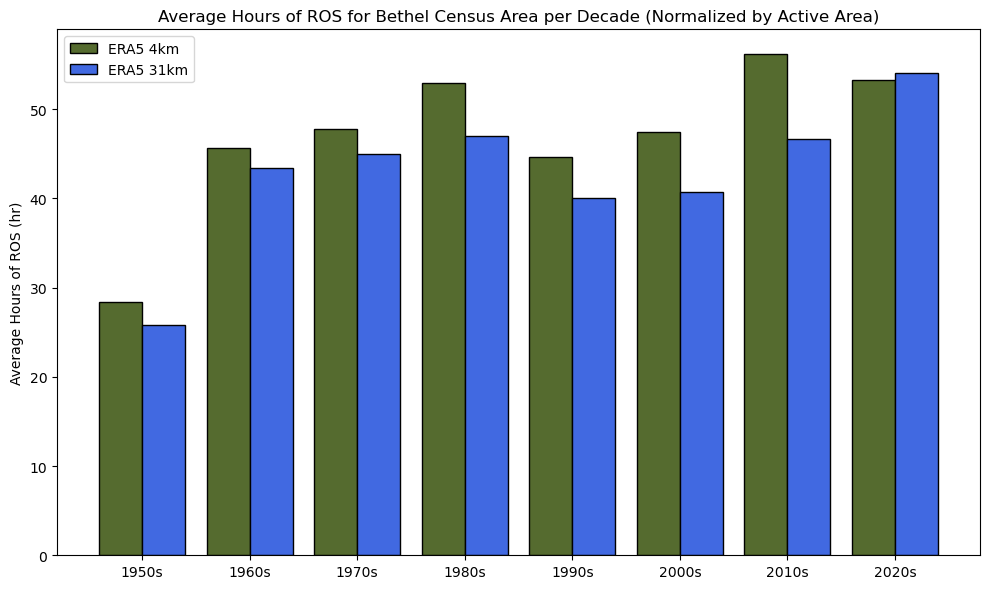

In [25]:
decades=['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

x = np.arange(len(decades))
width = 0.40
fig, ax = plt.subplots(figsize=(10,6))


ax.bar(x - 0.5*width, bet_decadal_means_4km , width, color='darkolivegreen', edgecolor='black', label='ERA5 4km')
ax.bar(x + 0.5*width, bet_decadal_means_31km , width, color='royalblue', edgecolor='black', label='ERA5 31km')

ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_ylabel('Average Hours of ROS (hr)')
ax.set_title('Average Hours of ROS for Bethel Census Area per Decade (Normalized by Active Area)')
ax.legend()
plt.tight_layout()
plt.show()

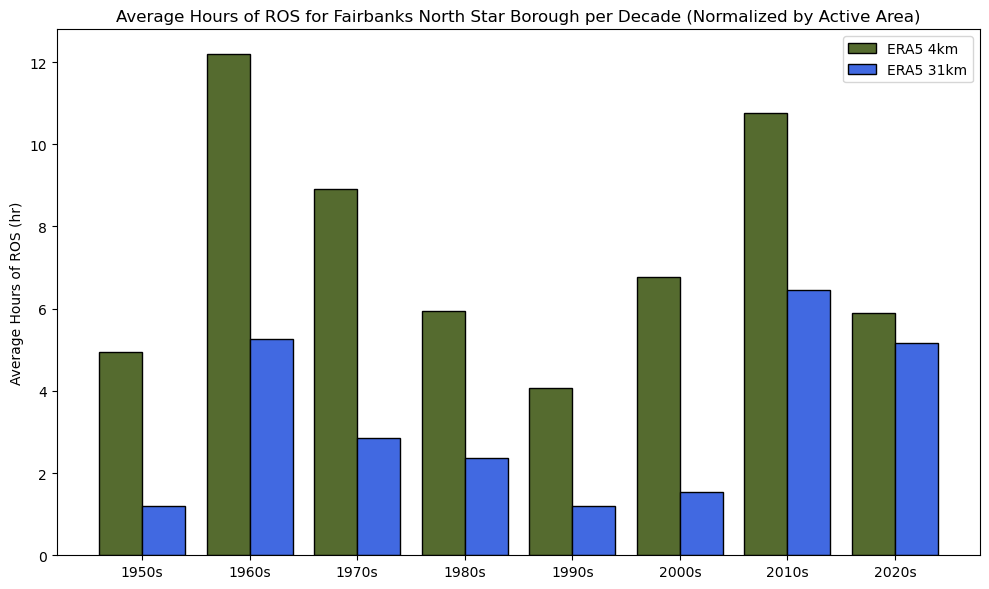

In [26]:
decades=['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

x = np.arange(len(decades))
width = 0.40
fig, ax = plt.subplots(figsize=(10,6))


ax.bar(x - 0.5*width, fai_decadal_means_4km , width, color='darkolivegreen', edgecolor='black', label='ERA5 4km')
ax.bar(x + 0.5*width, fai_decadal_means_31km , width, color='royalblue', edgecolor='black', label='ERA5 31km')

ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_ylabel('Average Hours of ROS (hr)')
ax.set_title('Average Hours of ROS for Fairbanks North Star Borough per Decade (Normalized by Active Area)')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
borough_colors = {
    'Anchorageold': "#5f7783",   # light blue
    "Anchoragenew": "#68d9eb",   # teal green
    "Fairbanksnew": "#e3985e",   # orange
    "Fairbanksold": "#A44D0A",   # orange
    "Bethelnew": "#9c98d2",      # purple
    "Bethelold": "#504e73",      # purple
    "Statewidenew": "#0072B2" ,   # blue
    "Statewideold": "#004c99"     # dark blue
}

average_colors = {
    "Anchorage": "#63a8b7",
    "Fairbanks": "#c37234",
    "Bethel": "#7673a2",
    "Statewide": "#005fa5"
}

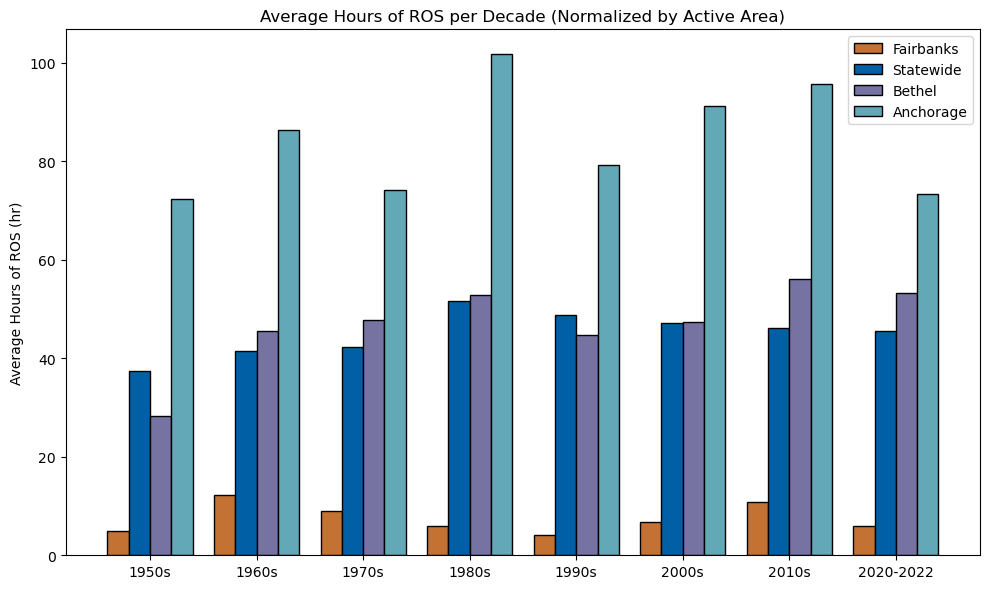

In [28]:
decades=['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020-2022']


x = np.arange(len(decades))
width = 0.20
fig, ax = plt.subplots(figsize=(10,6))
average_colors = [ "#63a8b7", "#c37234","#7673a2", "#005fa5"]

ax.bar(x - 1.5*width, fai_decadal_means_4km, width, color=average_colors[1], edgecolor='black', label='Fairbanks')
ax.bar(x - .5*width, decadal_means_4km, width, color=average_colors[3], edgecolor='black', label='Statewide')
ax.bar(x + 0.5*width, bet_decadal_means_4km, width, color=average_colors[2], edgecolor='black', label='Bethel')
ax.bar(x + 1.5*width, anc_decadal_means_4km, width, color=average_colors[0], edgecolor='black', label='Anchorage')

ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_ylabel('Average Hours of ROS (hr)')

ax.set_title('Average Hours of ROS per Decade (Normalized by Active Area)')
ax.legend()
plt.tight_layout()
plt.show()

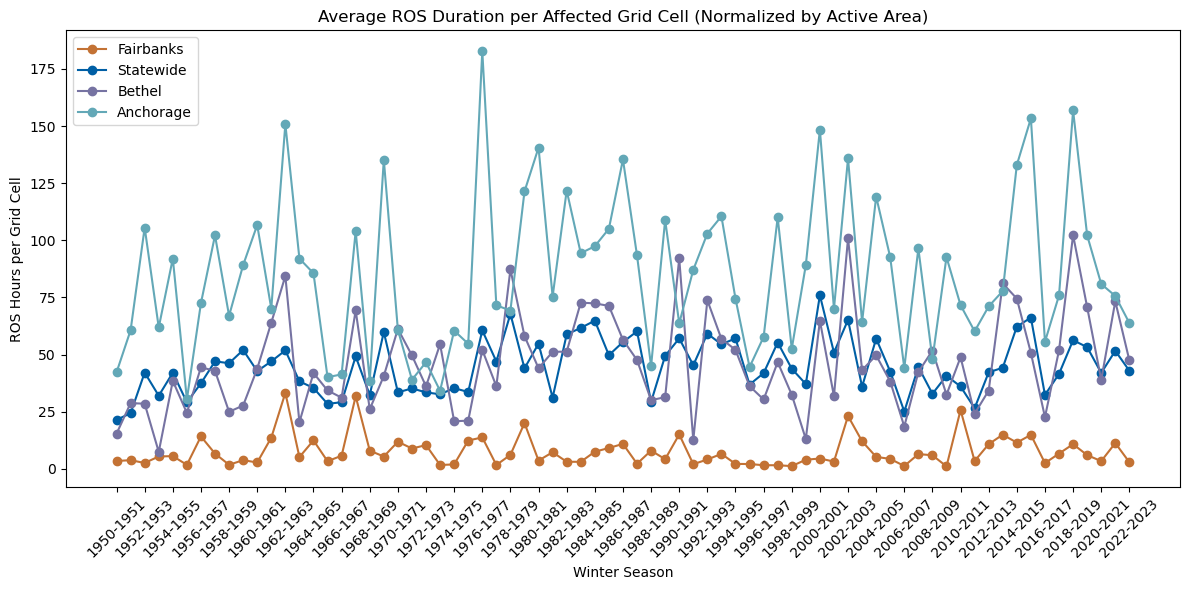

In [32]:
average_colors = [ "#63a8b7", "#c37234","#7673a2", "#005fa5"]

plt.figure(figsize=(12, 6))

plt.plot(seasons_4anc, fai_4km_normalized, marker='o', linestyle='-', color=average_colors[1],label='Fairbanks')
plt.plot(seasons_4anc, statewide_4km_normalized, marker='o', linestyle='-', color=average_colors[3],label='Statewide')
plt.plot(seasons_4anc, bet_4km_normalized, marker='o', linestyle='-', color=average_colors[2],label='Bethel')
plt.plot(seasons_4anc, anc_4km_normalized, marker='o', linestyle='-', color=average_colors[0],label='Anchorage')
plt.title('Average ROS Duration per Affected Grid Cell (Normalized by Active Area)')
plt.xlabel('Winter Season')
plt.ylabel('ROS Hours per Grid Cell')
plt.xticks(ticks=range(0, len(seasons), 2), labels=seasons[::2], rotation=45)
plt.tight_layout()
plt.legend()
#fig.patch.set_alpha(0.0)
plt.show()